In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import polars as pl

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
 
import torch
from lightning.pytorch import seed_everything, Trainer
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
from lightning.pytorch.loggers import CSVLogger

from src.classification.datamodule import Augmented_Dataset, LightCurveModule
from src.classification.model import CNNModel_Deep, CNNModel_Shallow, GRUModel
from src.classification.trainer import MultiClassClassifier


In [2]:
seed_everything(1337, workers = True)

augmented_lcs_path = "../data/combined_multi_class_augmented_lcs.parq"
original_lcs_path = "../data/combined_multi_class_original_lcs.parq"
test_lcs_path = "../data/combined_multi_class_original_test_lcs.parq"

augmented_data = pl.read_parquet(augmented_lcs_path)
original_data = pl.read_parquet(original_lcs_path)
test_data = pl.read_parquet(test_lcs_path)

test_ids = test_data["object_id"].to_numpy()


Seed set to 1337


## Deep CNN - best result 

### Pretrain

In [ ]:

pretrain_data_module = LightCurveModule(augmented_lcs_path, validation_fraction = 0.3, 
                               train_batch_size = 128, validation_batch_size = 64)
pretrain_data_module.setup()

pretrain_model = CNNModel_Deep()

pretrain_classifier = MultiClassClassifier(pretrain_model, optimiser = torch.optim.Adam, 
                                           learning_rate = 1e-3, sheduler_name = "CosineAnnealingLR",
                                           max_epochs = 750, weight = torch.Tensor([1, 1, 1]))

logger = CSVLogger(
    version = "deep_cnn_pretrain",
)  

checkpoint_callback = ModelCheckpoint(
    dirpath = "../models/pretrain/",
    filename = "best_pretrained_deep_cnn_model",
    monitor = "validation_f1_score",
    mode = "max",
    save_top_k = 1,
)

last_checkpoint_callback = ModelCheckpoint(
    dirpath = "../models/pretrain/",
    filename = f"last_pretrained_deep_cnn_model",
    save_last = True,
    save_top_k = 0,  
)

callbacks = [
    checkpoint_callback,
    last_checkpoint_callback,
    EarlyStopping(
        monitor = "validation_loss",
        min_delta = 0.001,
        patience = 25,
    ),
]

trainer = Trainer(
    enable_model_summary = False,
    num_sanity_val_steps = 2,
    max_epochs = 750,
    logger = logger, 
    check_val_every_n_epoch = 5,
    gradient_clip_val = 1.0,
    gradient_clip_algorithm = "norm",
    devices = 1,
    callbacks = callbacks,
)
trainer.fit(model = pretrain_classifier, datamodule = pretrain_data_module)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/umuzigazuba/Documents/School/Doctorate/Coding/AI4Science/models/pretrain exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (33) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 544: 100%|██████████| 33/33 [00:02<00:00, 11.06it/s, v_num=rain, train_loss=0.441, validation_loss=0.582, validation_accuracy=0.768, validation_f1_score=0.639] 


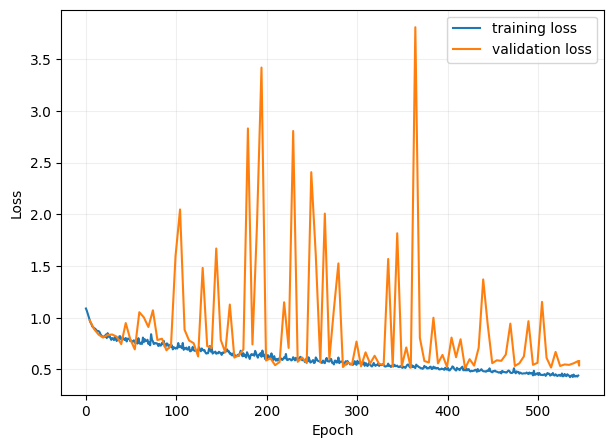

In [ ]:
pretrain_logs = pd.read_csv("lightning_logs/deep_cnn_pretrain/metrics.csv")

fig, ax = plt.subplots(figsize = (7, 5))

train_mask = ~np.isnan(pretrain_logs["train_loss"])
plt.plot(pretrain_logs["epoch"][train_mask], pretrain_logs["train_loss"][train_mask], label = "training loss")

validation_mask = ~np.isnan(pretrain_logs["validation_loss"])
plt.plot(pretrain_logs["epoch"][validation_mask], pretrain_logs["validation_loss"][validation_mask], label = "validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
ax.grid(True, alpha = 0.2)
ax.legend()
plt.show()

### Finetune 

In [ ]:

finetune_data_module = LightCurveModule(original_lcs_path, validation_fraction = 0.3, 
                               train_batch_size = 64, validation_batch_size = 32)
finetune_data_module.setup()

all_targets = torch.tensor([target for _, _, target in finetune_data_module.train_dataset])
weights_loss = torch.Tensor([len(all_targets) / (2 * (all_targets == tgt_nr).sum().item()) for tgt_nr in range(3)])

checkpoint = torch.load("../models/pretrain/best_pretrained_model")
state_dict = {k.replace("model.", ""): v for k, v in checkpoint['state_dict'].items()}

finetune_model = CNNModel_Deep()
finetune_model.load_state_dict(state_dict)
finetune_model.cnn.requires_grad_(False)

finetune_classifier = MultiClassClassifier(finetune_model, optimiser = torch.optim.Adam, 
                                           learning_rate = 1e-5, sheduler_name = "CosineAnnealingLR",
                                           max_epochs = 500, weight = weights_loss)

logger = CSVLogger(
    save_dir = "lightning_logs",
    version = "deep_cnn_finetune",
)  

checkpoint_callback = ModelCheckpoint(
    dirpath = "../models/finetune/",
    filename = "best_finetuned_deep_cnn_model",
    monitor = "validation_f1_score",
    mode = "max",
    save_top_k = 1,
)

last_checkpoint_callback = ModelCheckpoint(
    dirpath = "../models/finetune/",
    filename = f"last_finetuned_model",
    save_last = True,
    save_top_k = 0,  
)

callbacks = [
    checkpoint_callback,
    last_checkpoint_callback,
    EarlyStopping(
        monitor = "validation_loss",
        min_delta = 0.0001,
        patience = 15,
    ),
]

trainer = Trainer(
    enable_model_summary = False,
    num_sanity_val_steps = 2,
    max_epochs = 500,
    logger = logger, 
    check_val_every_n_epoch = 3,
    gradient_clip_val = 1.0,
    gradient_clip_algorithm = "norm",
    devices = 1,
    callbacks = callbacks,
)
trainer.fit(model = finetune_classifier, datamodule = finetune_data_module)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/umuzigazuba/Documents/School/Doctorate/Coding/AI4Science/models/finetune exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (34) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 214: 100%|██████████| 34/34 [00:01<00:00, 33.70it/s, v_num=0, train_loss=0.547, validation_loss=0.454, validation_accuracy=0.883, validation_f1_score=0.338]


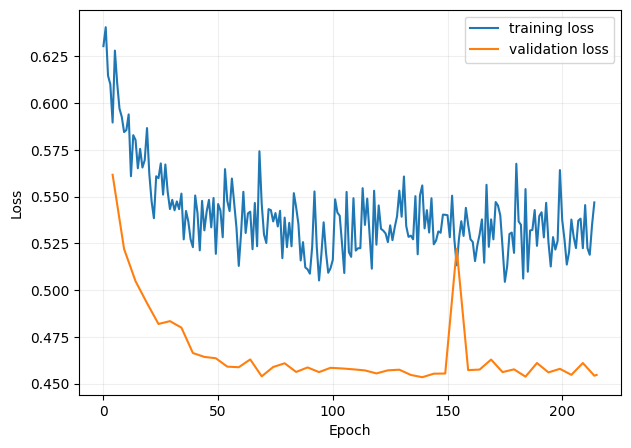

In [ ]:
finetune_logs = pd.read_csv("lightning_logs/deep_cnn_finetune/metrics.csv")

fig, ax = plt.subplots(figsize = (7, 5))

train_mask = ~np.isnan(finetune_logs["train_loss"])
plt.plot(finetune_logs["epoch"][train_mask], finetune_logs["train_loss"][train_mask], label = "training loss")

validation_mask = ~np.isnan(finetune_logs["validation_loss"])
plt.plot(finetune_logs["epoch"][validation_mask], finetune_logs["validation_loss"][validation_mask], label = "validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
ax.grid(True, alpha = 0.2)
ax.legend()
plt.show()

### Test

In [ ]:
test_dataset = Augmented_Dataset(test_lcs_path)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = 128, shuffle = False,
                                              generator=torch.Generator().manual_seed(1337),
)

checkpoint = torch.load("../models/finetune/best_finetuned_deep_cnn_model.ckpt")
state_dict = {k.replace("model.", ""): v for k, v in checkpoint['state_dict'].items()}

final_model = CNNModel_Deep()
final_model.load_state_dict(state_dict)

final_classifier = MultiClassClassifier(final_model, optimiser = torch.optim.Adam, 
                                        learning_rate = 1e-5, sheduler_name = "CosineAnnealingLR",
                                        max_epochs = 500, weight = torch.Tensor([1, 1, 1]))

final_classifier.eval()

trainer = Trainer(
    enable_model_summary = False,
    logger = False, 
    devices = 1,
)

batched_preds = trainer.predict(model = final_classifier, dataloaders = test_dataloader)
predictions = torch.cat(batched_preds).numpy()
 
predictions = np.where(predictions == 2, 1, 0)
 
submission_df = pd.DataFrame({"object_id": test_ids, "prediction": predictions}, columns = ["object_id", "prediction"])
submission_df.to_csv("../predictions/prediction_deep_cnn.csv", index = False)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the val

Predicting DataLoader 0: 100%|██████████| 56/56 [00:04<00:00, 13.01it/s]


## Shallow CNN 

### Pretrain

In [5]:

pretrain_data_module = LightCurveModule(augmented_lcs_path, validation_fraction = 0.3, 
                               train_batch_size = 128, validation_batch_size = 64)
pretrain_data_module.setup()

pretrain_model = CNNModel_Shallow()

pretrain_classifier = MultiClassClassifier(pretrain_model, optimiser = torch.optim.Adam, 
                                           learning_rate = 1e-3, sheduler_name = "CosineAnnealingLR",
                                           max_epochs = 750, weight = torch.Tensor([1, 1, 1]))

logger = CSVLogger(
    save_dir = "../notebooks",
    version = "shallow_cnn_pretrain",
)  

checkpoint_callback = ModelCheckpoint(
    dirpath = "../models/pretrain/",
    filename = "best_pretrained_shallow_cnn_model",
    monitor = "validation_f1_score",
    mode = "max",
    save_top_k = 1,
)

last_checkpoint_callback = ModelCheckpoint(
    dirpath = "../models/pretrain/",
    filename = f"last_pretrained_shallow_cnn_model",
    save_last = True,
    save_top_k = 0,  
)

callbacks = [
    checkpoint_callback,
    last_checkpoint_callback,
    EarlyStopping(
        monitor = "validation_loss",
        min_delta = 0.001,
        patience = 25,
    ),
]

trainer = Trainer(
    enable_model_summary = False,
    num_sanity_val_steps = 2,
    max_epochs = 750,
    logger = logger, 
    check_val_every_n_epoch = 5,
    gradient_clip_val = 1.0,
    gradient_clip_algorithm = "norm",
    devices = 1,
    callbacks = callbacks,
)
trainer.fit(model = pretrain_classifier, datamodule = pretrain_data_module)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/umuzigazuba/Documents/School/Doctorate/Coding/AI4Science/models/pretrain exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (33) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 499: 100%|██████████| 33/33 [00:01<00:00, 18.62it/s, v_num=rain, train_loss=0.640, validation_loss=0.626, validation_accuracy=0.715, validation_f1_score=0.580]  


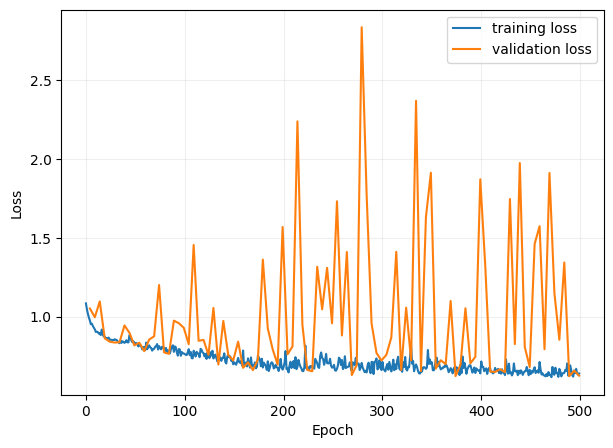

In [6]:
pretrain_logs = pd.read_csv("lightning_logs/shallow_cnn_pretrain/metrics.csv")

fig, ax = plt.subplots(figsize = (7, 5))

train_mask = ~np.isnan(pretrain_logs["train_loss"])
plt.plot(pretrain_logs["epoch"][train_mask], pretrain_logs["train_loss"][train_mask], label = "training loss")

validation_mask = ~np.isnan(pretrain_logs["validation_loss"])
plt.plot(pretrain_logs["epoch"][validation_mask], pretrain_logs["validation_loss"][validation_mask], label = "validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
ax.grid(True, alpha = 0.2)
ax.legend()
plt.show()

### Finetune 

In [7]:

finetune_data_module = LightCurveModule(original_lcs_path, validation_fraction = 0.3, 
                               train_batch_size = 64, validation_batch_size = 32)
finetune_data_module.setup()

all_targets = torch.tensor([target for _, _, target in finetune_data_module.train_dataset])
weights_loss = torch.Tensor([len(all_targets) / (2 * (all_targets == tgt_nr).sum().item()) for tgt_nr in range(3)])

checkpoint = torch.load("../models/pretrain/best_pretrained_shallow_cnn_model.ckpt")
state_dict = {k.replace("model.", ""): v for k, v in checkpoint['state_dict'].items()}

finetune_model = CNNModel_Shallow()
finetune_model.load_state_dict(state_dict)
finetune_model.cnn.requires_grad_(False)

finetune_classifier = MultiClassClassifier(finetune_model, optimiser = torch.optim.Adam, 
                                           learning_rate = 1e-5, sheduler_name = "CosineAnnealingLR",
                                           max_epochs = 500, weight = weights_loss)

logger = CSVLogger(
    save_dir = "../notebooks",
    version = "shallow_cnn_finetune",
)  

checkpoint_callback = ModelCheckpoint(
    dirpath = "../models/finetune/",
    filename = "best_finetuned_shallow_cnn_model",
    monitor = "validation_f1_score",
    mode = "max",
    save_top_k = 1,
)

last_checkpoint_callback = ModelCheckpoint(
    dirpath = "../models/finetune/",
    filename = f"last_finetuned_shallow_cnn_model",
    save_last = True,
    save_top_k = 0,  
)

callbacks = [
    checkpoint_callback,
    last_checkpoint_callback,
    EarlyStopping(
        monitor = "validation_loss",
        min_delta = 0.0001,
        patience = 15,
    ),
]

trainer = Trainer(
    enable_model_summary = False,
    num_sanity_val_steps = 2,
    max_epochs = 500,
    logger = logger, 
    check_val_every_n_epoch = 3,
    gradient_clip_val = 1.0,
    gradient_clip_algorithm = "norm",
    devices = 1,
    callbacks = callbacks,
)
trainer.fit(model = finetune_classifier, datamodule = finetune_data_module)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/umuzigazuba/Documents/School/Doctorate/Coding/AI4Science/models/finetune exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (34) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 245: 100%|██████████| 34/34 [00:00<00:00, 36.28it/s, v_num=tune, train_loss=0.624, validation_loss=0.623, validation_accuracy=0.842, validation_f1_score=0.279]


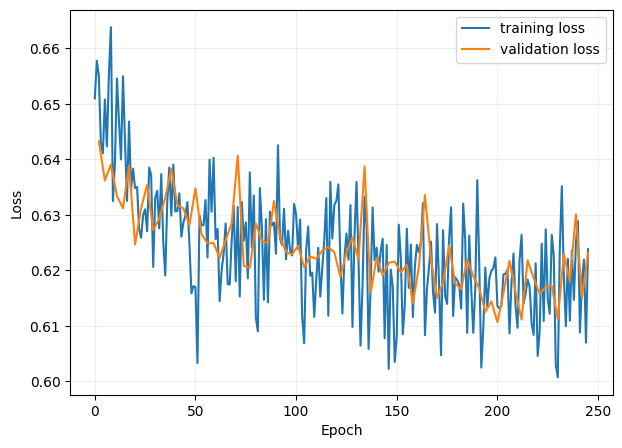

In [8]:
finetune_logs = pd.read_csv("lightning_logs/shallow_cnn_finetune/metrics.csv")

fig, ax = plt.subplots(figsize = (7, 5))

train_mask = ~np.isnan(finetune_logs["train_loss"])
plt.plot(finetune_logs["epoch"][train_mask], finetune_logs["train_loss"][train_mask], label = "training loss")

validation_mask = ~np.isnan(finetune_logs["validation_loss"])
plt.plot(finetune_logs["epoch"][validation_mask], finetune_logs["validation_loss"][validation_mask], label = "validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
ax.grid(True, alpha = 0.2)
ax.legend()
plt.show()

### Test

In [10]:
test_dataset = Augmented_Dataset(test_lcs_path)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = 128, shuffle = False,
                                              generator=torch.Generator().manual_seed(1337),
)

checkpoint = torch.load("../models/finetune/best_finetuned_shallow_cnn_model.ckpt")
state_dict = {k.replace("model.", ""): v for k, v in checkpoint['state_dict'].items()}

final_model = CNNModel_Shallow()
final_model.load_state_dict(state_dict)

final_classifier = MultiClassClassifier(final_model, optimiser = torch.optim.Adam, 
                                        learning_rate = 1e-5, sheduler_name = "CosineAnnealingLR",
                                        max_epochs = 500, weight = torch.Tensor([1, 1, 1]))

final_classifier.eval()

trainer = Trainer(
    enable_model_summary = False,
    logger = False, 
    devices = 1,
)

batched_preds = trainer.predict(model = final_classifier, dataloaders = test_dataloader)
predictions = torch.cat(batched_preds).numpy()
 
predictions = np.where(predictions == 2, 1, 0)
 
submission_df = pd.DataFrame({"object_id": test_ids, "prediction": predictions}, columns = ["object_id", "prediction"])
submission_df.to_csv("../predictions/prediction_shallow_cnn.csv", index = False)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the val

Predicting DataLoader 0: 100%|██████████| 56/56 [00:01<00:00, 32.42it/s]


## No transfer learning

In [13]:

data_module = LightCurveModule(original_lcs_path, validation_fraction = 0.3, 
                                        train_batch_size = 64, validation_batch_size = 32)
data_module.setup()

model = CNNModel_Deep()

all_targets = torch.tensor([target for _, _, target in data_module.train_dataset])
weights_loss = torch.Tensor([len(all_targets) / (2 * (all_targets == tgt_nr).sum().item()) for tgt_nr in range(3)])

classifier = MultiClassClassifier(model, optimiser = torch.optim.Adam, 
                                  learning_rate = 1e-3, sheduler_name = "CosineAnnealingLR",
                                  max_epochs = 750, weight = weights_loss)

logger = CSVLogger(
    save_dir = "../notebooks",
    version = "deep_cnn_original",
)

checkpoint_callback = ModelCheckpoint(
    dirpath = "../models/original/",
    filename = "best_original_deep_cnn_model",
    monitor = "validation_f1_score",
    mode = "max",
    save_top_k = 1,
)

last_checkpoint_callback = ModelCheckpoint(
    dirpath = "../models/original/",
    filename = f"last_original_deep_cnn_model",
    save_last = True,
    save_top_k = 0,  
)

callbacks = [
    checkpoint_callback,
    last_checkpoint_callback,
    EarlyStopping(
        monitor = "validation_loss",
        min_delta = 0.001,
        patience = 25,
    ),
]

trainer = Trainer(
    enable_model_summary = False,
    num_sanity_val_steps = 2,
    max_epochs = 750,
    logger = logger, 
    check_val_every_n_epoch = 5,
    gradient_clip_val = 1.0,
    gradient_clip_algorithm = "norm",
    devices = 1,
    callbacks = callbacks,
)
trainer.fit(model = classifier, datamodule = data_module)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/umuzigazuba/Documents/School/Doctorate/Coding/AI4Science/models/original exists and is not empty.


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (34) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 334: 100%|██████████| 34/34 [00:01<00:00, 28.44it/s, v_num=inal, train_loss=0.367, validation_loss=1.510, validation_accuracy=0.721, validation_f1_score=0.125]  


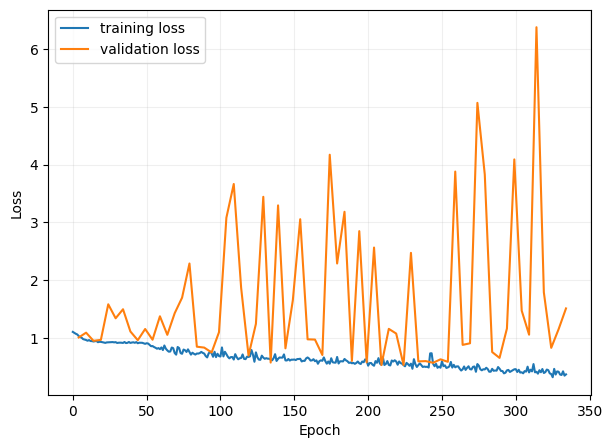

In [14]:
original_logs = pd.read_csv("lightning_logs/deep_cnn_original/metrics.csv")

fig, ax = plt.subplots(figsize = (7, 5))

train_mask = ~np.isnan(original_logs["train_loss"])
plt.plot(original_logs["epoch"][train_mask], original_logs["train_loss"][train_mask], label = "training loss")

validation_mask = ~np.isnan(original_logs["validation_loss"])
plt.plot(original_logs["epoch"][validation_mask], original_logs["validation_loss"][validation_mask], label = "validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
ax.grid(True, alpha = 0.2)
ax.legend()
plt.show()

### Test

In [15]:
test_dataset = Augmented_Dataset(test_lcs_path)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size = 128, shuffle = False,
                                              generator=torch.Generator().manual_seed(1337),
)

checkpoint = torch.load("../models/original/best_original_deep_cnn_model.ckpt")
state_dict = {k.replace("model.", ""): v for k, v in checkpoint['state_dict'].items()}

final_model = CNNModel_Deep()
final_model.load_state_dict(state_dict)

final_classifier = MultiClassClassifier(final_model, optimiser = torch.optim.Adam, 
                                        learning_rate = 1e-5, sheduler_name = "CosineAnnealingLR",
                                        max_epochs = 500, weight = torch.Tensor([1, 1, 1]))

final_classifier.eval()

trainer = Trainer(
    enable_model_summary = False,
    logger = False, 
    devices = 1,
)

batched_preds = trainer.predict(model = final_classifier, dataloaders = test_dataloader)
predictions = torch.cat(batched_preds).numpy()
 
predictions = np.where(predictions == 2, 1, 0)
 
submission_df = pd.DataFrame({"object_id": test_ids, "prediction": predictions}, columns = ["object_id", "prediction"])
submission_df.to_csv("../predictions/prediction_original_deep_cnn.csv", index = False)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/umuzigazuba/anaconda3/envs/mallorn_data_aug/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the val

Predicting DataLoader 0: 100%|██████████| 56/56 [00:01<00:00, 31.91it/s]
